In [4]:
import os
import sys
import json
import argparse
import numpy as np
import math
from einops import rearrange
import time
import random
import string
import h5py
from tqdm import tqdm
import webdataset as wds
import socket

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from accelerate import Accelerator, DeepSpeedPlugin

print("hostname:", socket.gethostname())
print("slurm job id:", os.environ.get("SLURM_JOB_ID"))
print("slurm node list:", os.environ.get("SLURM_JOB_NODELIST"))

from sentence_transformers import SentenceTransformer, util
from transformers import CLIPModel, AutoTokenizer, AutoProcessor
import evaluate
import pandas as pd

from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
from models import GNet8_Encoder

# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True

# custom functions #
import utils

accelerator = Accelerator(split_batches=False, mixed_precision="fp16")
device = accelerator.device
print("device:",device)

hostname: della-l01g12
slurm job id: 5486876
slurm node list: della-l01g12
device: cuda


In [5]:
# if running this interactively, can specify jupyter_args here for argparser to use
if utils.is_interactive():
    model_name = "subj01_noprior_40sess"
    model_name_safe = model_name.replace("/", "_")
    # This model is evaluated from the standard recon outputs.
    all_recons_path = f"evals/{model_name_safe}/{model_name_safe}_all_recons.pt"
    subj = 1
    
    data_path = "/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src"
    cache_dir = "/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src"
    
    print("model_name:", model_name)

    jupyter_args = f"--model_name={model_name} --subj={subj} --data_path={data_path} --cache_dir={cache_dir} --all_recons_path={all_recons_path}"
    print(jupyter_args)
    jupyter_args = jupyter_args.split()
    
    from IPython.display import clear_output # function to clear print outputs in cell
    %load_ext autoreload 
    # this allows you to change functions in models.py or utils.py and have this notebook automatically update with your revisions
    %autoreload 2 

model_name: subj01_noprior_40sess
--model_name=subj01_noprior_40sess --subj=1 --data_path=/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src --cache_dir=/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src --all_recons_path=evals/subj01_noprior_40sess/subj01_noprior_40sess_all_recons.pt


In [6]:
parser = argparse.ArgumentParser(description="Model Training Configuration")
parser.add_argument(
    "--model_name", type=str, default="testing",
    help="name of model, used for ckpt saving and wandb logging (if enabled)",
)
parser.add_argument(
    "--all_recons_path", type=str,
    help="Path to where all_recons.pt is stored",
)
parser.add_argument(
    "--data_path", type=str, default=os.getcwd(),
    help="Path to where NSD data is stored / where to download it to",
)
parser.add_argument(
    "--cache_dir", type=str, default=os.getcwd(),
    help="Path to where misc. files downloaded from huggingface are stored. Defaults to current src directory.",
)
parser.add_argument(
    "--subj",type=int, default=1, choices=[1,2,3,4,5,6,7,8],
    help="Evaluate on which subject?",
)
parser.add_argument(
    "--seed",type=int,default=42,
)
if utils.is_interactive():
    args = parser.parse_args(jupyter_args)
else:
    args = parser.parse_args()

# create global variables without the args prefix
for attribute_name in vars(args).keys():
    globals()[attribute_name] = getattr(args, attribute_name)

# model_name_safe for paths (handles ViTSmall/mix_2head_addpressure)
model_name_safe = model_name.replace("/", "_")
if all_recons_path is None:
    suffix = "_all_recons" if "ViTSmall" in model_name else "_all_enhancedrecons"
    all_recons_path = f"evals/{model_name_safe}/{model_name_safe}{suffix}.pt"
    
# seed all random functions
utils.seed_everything(seed)

# Evals

In [7]:
# Load ground truths, you can find these files on huggingface: https://huggingface.co/datasets/pscotti/mindeyev2/tree/main/evals
all_images = torch.load(f"evals/all_images.pt", weights_only=False)
all_captions = torch.load(f"evals/all_captions.pt", weights_only=False)


In [8]:
print("all_recons_path:", all_recons_path)
all_recons = torch.load(all_recons_path)

# Residual submodule
all_clipvoxels = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_clipvoxels.pt")
# Low-level submodule
all_blurryrecons = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_blurryrecons.pt")
# GIT predicted captions
all_predcaptions = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_predcaptions.pt", weights_only=False)

# model name (2head uses all_recons, not enhanced)
model_name_plus_suffix = f"{model_name_safe}_all_recons" if "ViTSmall" in model_name else f"{model_name_safe}_all_enhancedrecons"
print(model_name_plus_suffix)
print(all_images.shape, all_recons.shape)

all_recons_path: evals/ViTSmall_mix_2head_addpressure/ViTSmall_mix_2head_addpressure_all_recons.pt
ViTSmall_mix_2head_addpressure_all_recons
torch.Size([1000, 3, 224, 224]) torch.Size([1000, 3, 256, 256])


In [16]:
# # Create full grid of recon comparisons 
# from PIL import Image

# imsize = 150
# if all_images.shape[-1] != imsize:
#     all_images = transforms.Resize((imsize,imsize))(all_images).float()
# if all_recons.shape[-1] != imsize:
#     all_recons = transforms.Resize((imsize,imsize))(all_recons).float()

# num_images = all_recons.shape[0]
# num_rows = (2 * num_images + 9) // 10

# # Interleave tensors
# merged = torch.stack([val for pair in zip(all_images, all_recons) for val in pair], dim=0)

# # Calculate grid size
# grid = torch.zeros((num_rows * 10, 3, all_recons.shape[-1], all_recons.shape[-1]))

# # Populate the grid
# grid[:2*num_images] = merged
# grid_images = [transforms.functional.to_pil_image(grid[i]) for i in range(num_rows * 10)]

# # Create the grid image
# grid_image = Image.new('RGB', (all_recons.shape[-1]*10, all_recons.shape[-1] * num_rows))  # 10 images wide

# # Paste images into the grid
# for i, img in enumerate(grid_images):
#     grid_image.paste(img, (all_recons.shape[-1] * (i % 10), all_recons.shape[-1] * (i // 10)))

# grid_image.save(f"{model_name_plus_suffix[:-3]}_1000recons.png")

In [9]:
imsize = 256
if all_images.shape[-1] != imsize:
    all_images = transforms.Resize((imsize,imsize))(all_images).float()
if all_recons.shape[-1] != imsize:
    all_recons = transforms.Resize((imsize,imsize))(all_recons).float()
if all_blurryrecons.shape[-1] != imsize:
    all_blurryrecons = transforms.Resize((imsize,imsize))(all_blurryrecons).float()
    
if "enhanced" in model_name_plus_suffix:
    print("weighted averaging to improve low-level evals")
    all_recons = all_recons*.75 + all_blurryrecons*.25

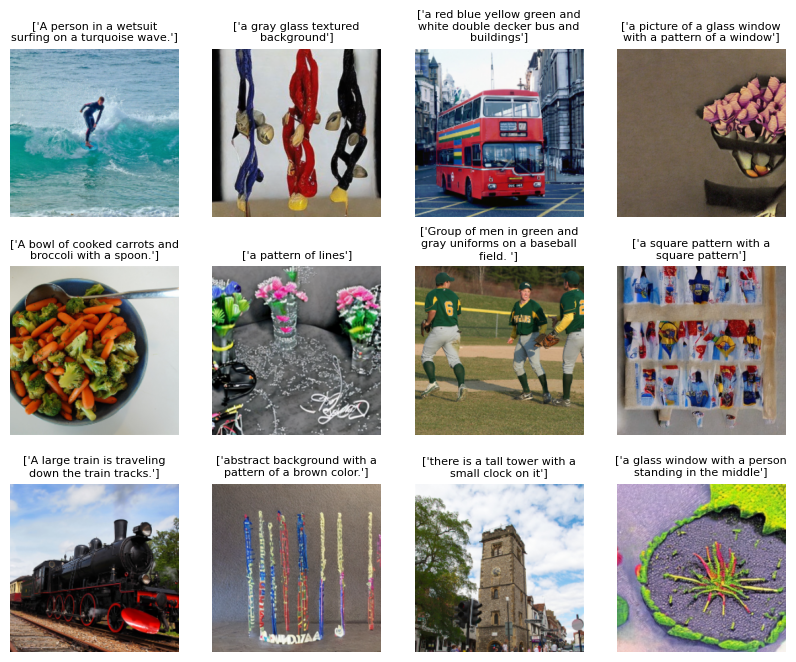

In [10]:
# 2 / 117 / 231 / 164 / 619 / 791
import textwrap
def wrap_title(title, wrap_width):
    return "\n".join(textwrap.wrap(title, wrap_width))

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
jj=-1; kk=0;
for j in np.array([2,165,119,619,231,791]):
    jj+=1
    # print(kk,jj)
    axes[kk][jj].imshow(utils.torch_to_Image(all_images[j]))
    axes[kk][jj].axis('off')
    axes[kk][jj].set_title(wrap_title(str(all_captions[[j]]),wrap_width=30), fontsize=8)
    jj+=1
    axes[kk][jj].imshow(utils.torch_to_Image(all_recons[j]))
    axes[kk][jj].axis('off')
    axes[kk][jj].set_title(wrap_title(str(all_predcaptions[[j]]),wrap_width=30), fontsize=8)
    if jj==3: 
        kk+=1; jj=-1

# Retrieval eval

In [11]:
# Load embedding model (ViT-L-14 for ViTSmall/2head, ViT-bigG for standard)
use_vitsmall = "ViTSmall" in model_name
if use_vitsmall:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-L-14",
        version="laion2b_s32b_b82k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_seq_dim = 128
    clip_emb_dim = 768
else:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_seq_dim = 256
    clip_emb_dim = 1664
clip_img_embedder.to(device)

'[Errno -2] Name or service not known' thrown while requesting HEAD https://huggingface.co/laion/CLIP-ViT-L-14-laion2B-s32B-b82K/resolve/main/open_clip_model.safetensors
Retrying in 1s [Retry 1/5].


FrozenOpenCLIPImageEmbedder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-23): 24 x ResidualAttentionBlock(
            (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
            )
            (ls_2): Identity()


In [13]:
from scipy import stats
percent_correct_fwds, percent_correct_bwds = [], []
percent_correct_fwd, percent_correct_bwd = None, None

with torch.cuda.amp.autocast(dtype=torch.float16):
    for test_i, loop in enumerate(tqdm(range(30))):
        random_samps = np.random.choice(np.arange(len(all_images)), size=300, replace=False)
        emb = clip_img_embedder(all_images[random_samps].to(device)).float() # CLIP-Image

        emb_ = all_clipvoxels[random_samps].to(device).float() # CLIP-Brain

        # Reduce 256 GT tokens down to 128 tokens by grouping and averaging (matching training logic)
        if emb.shape[1] == 256 and emb_.shape[1] == 128:
            emb = emb.reshape(emb.shape[0], 128, 2, emb.shape[-1]).mean(dim=2)
        elif emb.shape[1] != emb_.shape[1]:
            # Fallback to linear interpolation (as handled in reduce_clip_tokens)
            emb = nn.functional.interpolate(
                emb.transpose(1, 2), size=emb_.shape[1], mode='linear', align_corners=False
            ).transpose(1, 2)

        # flatten if necessary
        emb = emb.reshape(len(emb),-1)
        emb_ = emb_.reshape(len(emb_),-1)

        # l2norm 
        emb = nn.functional.normalize(emb,dim=-1)
        emb_ = nn.functional.normalize(emb_,dim=-1)

        labels = torch.arange(len(emb)).to(device)
        bwd_sim = utils.batchwise_cosine_similarity(emb,emb_)  # clip, brain
        fwd_sim = utils.batchwise_cosine_similarity(emb_,emb)  # brain, clip

        assert len(bwd_sim) == 300

        percent_correct_fwds = np.append(percent_correct_fwds, utils.topk(fwd_sim, labels,k=1).item())
        percent_correct_bwds = np.append(percent_correct_bwds, utils.topk(bwd_sim, labels,k=1).item())

        if test_i==0:
            print("Loop 0:",percent_correct_fwds, percent_correct_bwds)
            
percent_correct_fwd = np.mean(percent_correct_fwds)
fwd_sd = np.std(percent_correct_fwds) / np.sqrt(len(percent_correct_fwds))
fwd_ci = stats.norm.interval(0.95, loc=percent_correct_fwd, scale=fwd_sd)

percent_correct_bwd = np.mean(percent_correct_bwds)
bwd_sd = np.std(percent_correct_bwds) / np.sqrt(len(percent_correct_bwds))
bwd_ci = stats.norm.interval(0.95, loc=percent_correct_bwd, scale=bwd_sd)

print(f"fwd percent_correct: {percent_correct_fwd:.4f} 95% CI: [{fwd_ci[0]:.4f},{fwd_ci[1]:.4f}]")
print(f"bwd percent_correct: {percent_correct_bwd:.4f} 95% CI: [{bwd_ci[0]:.4f},{bwd_ci[1]:.4f}]")

fwd_sim = np.array(fwd_sim.cpu())
bwd_sim = np.array(bwd_sim.cpu())

/tmp/ipykernel_1612520/3224514972.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):
  3%|█████▋                                                                                                                                                                   | 1/30 [00:01<00:35,  1.23s/it]

Loop 0: [0.22] [0.2]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:30<00:00,  1.01s/it]

fwd percent_correct: 0.2224 95% CI: [0.2133,0.2316]
bwd percent_correct: 0.1986 95% CI: [0.1911,0.2060]



/tmp/ipykernel_1612520/3224514972.py:52: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fwd_sim = np.array(fwd_sim.cpu())
/tmp/ipykernel_1612520/3224514972.py:53: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  bwd_sim = np.array(bwd_sim.cpu())


Given Brain embedding, find correct Image embedding


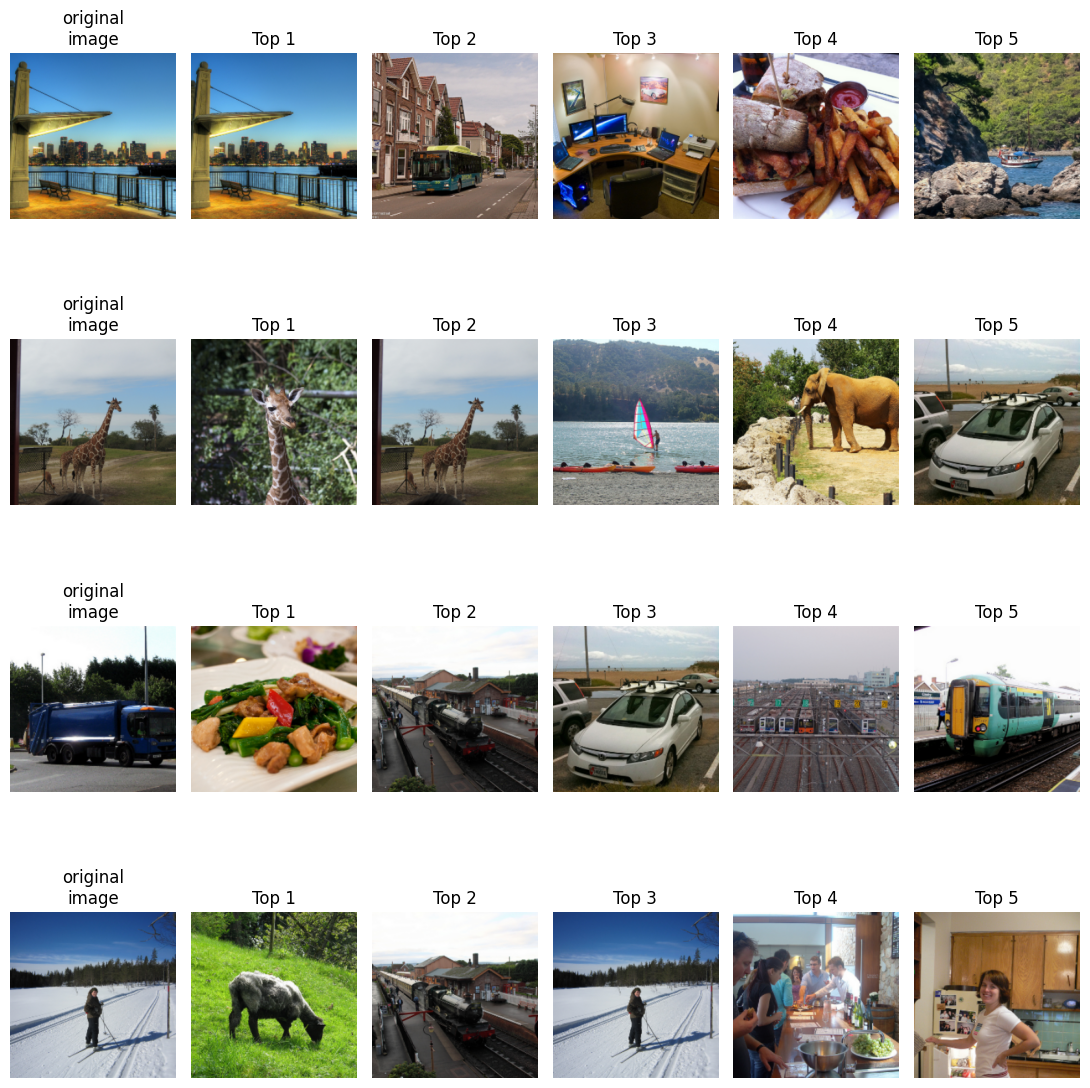

In [14]:
print("Given Brain embedding, find correct Image embedding")
fig, ax = plt.subplots(nrows=4, ncols=6, figsize=(11,12))
for trial in range(4):
    ax[trial, 0].imshow(utils.torch_to_Image(all_images[random_samps][trial]))
    ax[trial, 0].set_title("original\nimage")
    ax[trial, 0].axis("off")
    for attempt in range(5):
        which = np.flip(np.argsort(fwd_sim[trial]))[attempt]
        ax[trial, attempt+1].imshow(utils.torch_to_Image(all_images[random_samps][which]))
        ax[trial, attempt+1].set_title(f"Top {attempt+1}")
        ax[trial, attempt+1].axis("off")
fig.tight_layout()
plt.show()

## 2-way identification

In [15]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

@torch.no_grad()
def two_way_identification(all_recons, all_images, model, preprocess, feature_layer=None, return_avg=True):
    preds = model(torch.stack([preprocess(recon) for recon in all_recons], dim=0).to(device))
    reals = model(torch.stack([preprocess(indiv) for indiv in all_images], dim=0).to(device))
    if feature_layer is None:
        preds = preds.float().flatten(1).cpu().numpy()
        reals = reals.float().flatten(1).cpu().numpy()
    else:
        preds = preds[feature_layer].float().flatten(1).cpu().numpy()
        reals = reals[feature_layer].float().flatten(1).cpu().numpy()

    r = np.corrcoef(reals, preds)
    r = r[:len(all_images), len(all_images):]
    congruents = np.diag(r)

    success = r < congruents
    success_cnt = np.sum(success, 0)

    if return_avg:
        perf = np.mean(success_cnt) / (len(all_images)-1)
        return perf
    else:
        return success_cnt, len(all_images)-1

## PixCorr

In [16]:
preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR),
])

# Flatten images while keeping the batch dimension
all_images_flattened = preprocess(all_images).reshape(len(all_images), -1).cpu()
all_recons_flattened = preprocess(all_recons).view(len(all_recons), -1).cpu()

print(all_images_flattened.shape)
print(all_recons_flattened.shape)

corrsum = 0
for i in tqdm(range(len(all_images))):
    corrsum += np.corrcoef(all_images_flattened[i], all_recons_flattened[i])[0][1]
corrmean = corrsum / len(all_images)

pixcorr = corrmean
print(pixcorr)

torch.Size([1000, 541875])
torch.Size([1000, 541875])


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 293.20it/s]

0.017145754671610416


## SSIM

In [17]:
# see https://github.com/zijin-gu/meshconv-decoding/issues/3
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity as ssim

preprocess = transforms.Compose([
    transforms.Resize(425, interpolation=transforms.InterpolationMode.BILINEAR), 
])

# convert image to grayscale with rgb2grey
img_gray = rgb2gray(preprocess(all_images).permute((0,2,3,1)).cpu())
recon_gray = rgb2gray(preprocess(all_recons).permute((0,2,3,1)).cpu())
print("converted, now calculating ssim...")

ssim_score=[]
for im,rec in tqdm(zip(img_gray,recon_gray),total=len(all_images)):
    ssim_score.append(ssim(rec, im, multichannel=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False, data_range=1.0))

ssim = np.mean(ssim_score)
print(ssim)

converted, now calculating ssim...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 93.31it/s]

0.24160878204326713


## AlexNet

In [18]:
from torchvision.models import alexnet, AlexNet_Weights
alex_weights = AlexNet_Weights.IMAGENET1K_V1

alex_model = create_feature_extractor(alexnet(weights=alex_weights), return_nodes=['features.4','features.11']).to(device)
alex_model.eval().requires_grad_(False)

# see alex_weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

layer = 'early, AlexNet(2)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.4')
alexnet2 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet2:.4f}")

layer = 'mid, AlexNet(5)'
print(f"\n---{layer}---")
all_per_correct = two_way_identification(all_recons.to(device).float(), all_images, 
                                                          alex_model, preprocess, 'features.11')
alexnet5 = np.mean(all_per_correct)
print(f"2-way Percent Correct: {alexnet5:.4f}")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/aw1907/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


URLError: <urlopen error [Errno -2] Name or service not known>

## InceptionV3

In [19]:
from torchvision.models import inception_v3, Inception_V3_Weights
weights = Inception_V3_Weights.DEFAULT
inception_model = create_feature_extractor(inception_v3(weights=weights), 
                                           return_nodes=['avgpool']).to(device)
inception_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(342, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

all_per_correct = two_way_identification(all_recons, all_images,
                                        inception_model, preprocess, 'avgpool')
        
inception = np.mean(all_per_correct)
print(f"2-way Percent Correct: {inception:.4f}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/aw1907/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


URLError: <urlopen error [Errno -2] Name or service not known>

## CLIP

In [20]:
import clip
clip_model, preprocess = clip.load("ViT-L/14", device=device)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])

all_per_correct = two_way_identification(all_recons, all_images,
                                        clip_model.encode_image, preprocess, None) # final layer
clip_ = np.mean(all_per_correct)
print(f"2-way Percent Correct: {clip_:.4f}")

2-way Percent Correct: 0.4822


## Efficient Net

In [21]:
import scipy as sp
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
weights = EfficientNet_B1_Weights.DEFAULT
eff_model = create_feature_extractor(efficientnet_b1(weights=weights), 
                                    return_nodes=['avgpool'])
eff_model.eval().requires_grad_(False)

# see weights.transforms()
preprocess = transforms.Compose([
    transforms.Resize(255, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = eff_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = eff_model(preprocess(all_recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

effnet = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",effnet)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /home/aw1907/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


URLError: <urlopen error [Errno -2] Name or service not known>

## SwAV

In [22]:
swav_model = torch.hub.load('facebookresearch/swav:main', 'resnet50')
swav_model = create_feature_extractor(swav_model, 
                                    return_nodes=['avgpool'])
swav_model.eval().requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gt = swav_model(preprocess(all_images))['avgpool']
gt = gt.reshape(len(gt),-1).cpu().numpy()
fake = swav_model(preprocess(all_recons))['avgpool']
fake = fake.reshape(len(fake),-1).cpu().numpy()

swav = np.array([sp.spatial.distance.correlation(gt[i],fake[i]) for i in range(len(gt))]).mean()
print("Distance:",swav)

URLError: <urlopen error [Errno -2] Name or service not known>

# Brain Correlation
### Load brain data, brain masks, image lists

In [23]:
# Load brain data as ground truth
def my_split_by_node(urls): return urls

voxels = {}
# Load hdf5 data for betas
f = h5py.File(f'{data_path}/betas_all_subj0{subj}_fp32_renorm.hdf5', 'r')
betas = f['betas'][:]
betas = torch.Tensor(betas).to("cpu")
f.close()
num_voxels = betas[0].shape[-1]
voxels[f'subj0{subj}'] = betas
print(f"num_voxels for subj0{subj}: {num_voxels}")

if subj==3:
    num_test=2371
elif subj==4:
    num_test=2188
elif subj==6:
    num_test=2371
elif subj==8:
    num_test=2188
else:
    num_test=3000
test_url = f"{data_path}/wds/subj0{subj}/new_test/" + "0.tar"
    
print(test_url)
test_data = wds.WebDataset(test_url,resampled=False,nodesplitter=my_split_by_node)\
                    .decode("torch")\
                    .rename(behav="behav.npy", past_behav="past_behav.npy", future_behav="future_behav.npy", olds_behav="olds_behav.npy")\
                    .to_tuple(*["behav", "past_behav", "future_behav", "olds_behav"])
test_dl = torch.utils.data.DataLoader(test_data, batch_size=num_test, shuffle=False, drop_last=True, pin_memory=True)
print(f"Loaded test dl for subj{subj}!\n")

num_voxels for subj01: 15724
/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src/wds/subj01/new_test/0.tar
Loaded test dl for subj1!



/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src/fmri/lib/python3.12/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [24]:
# Prep test voxels and indices of test images
test_images_idx = []
for test_i, (behav, past_behav, future_behav, old_behav) in enumerate(test_dl):
    test_voxels = voxels[f'subj0{subj}'][behav[:,0,5].cpu().long()]
    test_images_idx = np.append(test_images_idx, behav[:,0,0].cpu().numpy())
test_images_idx = test_images_idx.astype(int)

assert (test_i+1) * num_test == len(test_voxels) == len(test_images_idx)
print(test_i, len(test_voxels), len(test_images_idx), len(np.unique(test_images_idx)))

0 3000 3000 1000


In [25]:
# Load brain region masks
brain_region_masks = {}
with h5py.File("brain_region_masks.hdf5", "r") as file:
    # Iterate over each subject
    for subject in file.keys():
        subject_group = file[subject]
        # Load the masks data for each subject
        subject_masks = {"nsd_general" : subject_group["nsd_general"][:],
                         "V1" : subject_group["V1"][:], 
                         "V2" : subject_group["V2"][:], 
                         "V3" : subject_group["V3"][:], 
                         "V4" : subject_group["V4"][:],
                         "higher_vis" : subject_group["higher_vis"][:]}
        brain_region_masks[subject] = subject_masks
subject_masks = brain_region_masks[f"subj0{subj}"]

# Average voxels of test set across trial repetitions for brain correlation scores
test_voxels_averaged = torch.zeros((len(np.unique(test_images_idx)),num_voxels))
# i = 0
uniq_imgs = np.unique(test_images_idx)
for i, uniq_img in enumerate(uniq_imgs):
    locs = np.where(test_images_idx==uniq_img)[0]
    if len(locs)==1:
        locs = locs.repeat(3)
    elif len(locs)==2:
        locs = locs.repeat(2)[:3]
    assert len(locs)==3
    test_voxels_averaged[i] = torch.mean(test_voxels[None,locs], dim=1)

# Prepare image list for input to GNet
recon_list = []
for i in range(all_recons.shape[0]):
    img = all_recons[i].detach()
    img = transforms.ToPILImage()(img)
    recon_list.append(img)

### Calculate Brain Correlation scores for each brain area

In [26]:
from torchmetrics import PearsonCorrCoef
GNet = GNet8_Encoder(device=device,subject=subj,model_path=f"{cache_dir}/gnet_multisubject.pt")
PeC = PearsonCorrCoef(num_outputs=len(recon_list))
beta_primes = GNet.predict(recon_list)

region_brain_correlations = {}
for region, mask in subject_masks.items():
    score = PeC(test_voxels_averaged[:,mask].moveaxis(0,1), beta_primes[:,mask].moveaxis(0,1))
    region_brain_correlations[region] = float(torch.mean(score))
print(region_brain_correlations)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor

In [ ]:
# Create a dictionary to store variable names and their corresponding values
import pandas as pd
data = {
    "Metric": ["PixCorr", "SSIM", "AlexNet(2)", "AlexNet(5)", "InceptionV3", "CLIP", "EffNet-B", "SwAV", "FwdRetrieval", "BwdRetrieval",
               "Brain Corr. nsd_general", "Brain Corr. V1", "Brain Corr. V2", "Brain Corr. V3", "Brain Corr. V4",  "Brain Corr. higher_vis"],
    "Value": [pixcorr, ssim, alexnet2, alexnet5, inception, clip_, effnet, swav, percent_correct_fwd, percent_correct_bwd, 
              region_brain_correlations["nsd_general"], region_brain_correlations["V1"], region_brain_correlations["V2"], region_brain_correlations["V3"], region_brain_correlations["V4"], region_brain_correlations["higher_vis"]]}

df = pd.DataFrame(data)
print(model_name_plus_suffix)
print(df.to_string(index=False))
print(df["Value"].to_string(index=False))

# save table to txt file
os.makedirs('tables/',exist_ok=True)
df["Value"].to_csv(f'tables/{model_name_plus_suffix}.csv', sep='\t', index=False)

# Captions evaluation


In [27]:
all_git_generated_captions = torch.load(f"evals/all_git_generated_captions.pt")

## Meteor

In [28]:
meteor = evaluate.load('meteor')
meteor_img_ref=meteor.compute(predictions=all_git_generated_captions,references=all_captions)
meteor_brain_ref=meteor.compute(predictions=all_predcaptions,references=all_captions)
meteor_brain_img=meteor.compute(predictions=all_predcaptions,references=all_git_generated_captions)


relative_brain_image_meteor=meteor_brain_img["meteor"]/meteor_img_ref["meteor"]

print(f"[GROUND] METEOR GIT from images vs captions: {meteor_img_ref['meteor']}")
print(f"[ABSOLUTE] METEOR GIT from brain vs captions: {meteor_brain_ref['meteor']}")
print(f"[ABSOLUTE] METEOR GIT from brain vs images: {meteor_brain_img['meteor']}")
print(f"[RELATIVE] METEOR  {relative_brain_image_meteor}")

FileNotFoundError: Couldn't find a module script at /scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src/meteor/meteor.py. Module 'meteor' doesn't exist on the Hugging Face Hub either.

## Rouge

In [29]:
rouge = evaluate.load('rouge')
rouge_img_ref=rouge.compute(predictions=all_git_generated_captions,references=all_captions)
rouge_brain_ref=rouge.compute(predictions=all_predcaptions,references=all_captions)
rouge_brain_img=rouge.compute(predictions=all_predcaptions,references=all_git_generated_captions)


relative_brain_image_rouge1 = rouge_brain_img['rouge1']/rouge_img_ref['rouge1']
relative_brain_image_rougeL = rouge_brain_img['rougeL']/rouge_img_ref['rougeL']

print(f"[GROUND] ROUGE-1 GIT from images vs captions: {rouge_img_ref['rouge1']}")
print(f"[ABSOLUTE] ROUGE-1 GIT from brain vs captions: {rouge_brain_ref['rouge1']}")
print(f"[ABSOLUTE] ROUGE-1 GIT from brain vs images: {rouge_brain_img['rouge1']}")
print(f"[RELATIVE] ROUGE-1  {relative_brain_image_rouge1}")

print(f"[GROUND] ROUGE-L GIT from images vs captions: {rouge_img_ref['rougeL']}")
print(f"[ABSOLUTE] ROUGE-L GIT from brain vs captions: {rouge_brain_ref['rougeL']}")
print(f"[ABSOLUTE] ROUGE-L GIT from brain vs images: {rouge_brain_img['rougeL']}")
print(f"[RELATIVE] ROUGE-L  {relative_brain_image_rougeL}")

FileNotFoundError: Couldn't find a module script at /scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src/rouge/rouge.py. Module 'rouge' doesn't exist on the Hugging Face Hub either.

## Sentence transformer

In [30]:
sentence_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')


with torch.no_grad():
    embedding_brain= sentence_model.encode(all_predcaptions, convert_to_tensor=True)
    embedding_captions = sentence_model.encode(all_captions, convert_to_tensor=True)
    embedding_images = sentence_model.encode(all_git_generated_captions, convert_to_tensor=True)

    ss_sim_brain_img=util.pytorch_cos_sim(embedding_brain, embedding_images).cpu()
    ss_sim_brain_cap=util.pytorch_cos_sim(embedding_brain, embedding_captions).cpu()
    ss_sim_img_cap=util.pytorch_cos_sim(embedding_images, embedding_captions).cpu()

    relative_brain_image_ss=ss_sim_brain_img.diag().mean()/ss_sim_img_cap.diag().mean()

'[Errno -2] Name or service not known' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'[Errno -2] Name or service not known' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

In [31]:
print(f"[GROUND] Sentence Transformer Similarity GIT from images vs captions: {ss_sim_img_cap.diag().mean()}")
print(f"[ABSOLUTE] Sentence Transformer Similarity GIT from brain vs captions: {ss_sim_brain_cap.diag().mean()}")
print(f"[ABSOLUTE] Sentence Transformer Similarity GIT from brain vs images: {ss_sim_brain_img.diag().mean()}")
print(f"[RELATIVE] Sentence Transformer Similarity   {relative_brain_image_ss.mean()}")

NameError: name 'ss_sim_img_cap' is not defined

## CLIP

#### CLIP-B

In [32]:
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor_clip = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
tokenizer =  AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")

with torch.no_grad():
    input_ids=tokenizer(list(all_predcaptions),return_tensors="pt",padding=True)
    embedding_brain= model_clip.get_text_features(**input_ids)

    input_ids=tokenizer(list(all_captions),return_tensors="pt",padding=True)
    embedding_captions= model_clip.get_text_features(**input_ids)

    input_ids=tokenizer(all_git_generated_captions,return_tensors="pt",padding=True)
    embedding_images= model_clip.get_text_features(**input_ids)

clip_B_sim_brain_img=util.pytorch_cos_sim(embedding_brain, embedding_images).cpu()
clip_B_sim_brain_cap=util.pytorch_cos_sim(embedding_brain, embedding_captions).cpu()
clip_B_sim_img_cap=util.pytorch_cos_sim(embedding_images, embedding_captions).cpu()

relative_brain_image_clip_B=clip_B_sim_brain_img.diag().mean()/clip_B_sim_img_cap.diag().mean()

print(f"[GROUND] CLIP Similarity GIT from images vs captions: {clip_B_sim_img_cap.diag().mean()}")
print(f"[ABSOLUTE] CLIP Similarity GIT from brain vs captions: {clip_B_sim_brain_cap.diag().mean()}")
print(f"[ABSOLUTE] CLIP Similarity GIT from brain vs images: {clip_B_sim_brain_img.diag().mean()}")
print(f"[RELATIVE] CLIP Similarity   {relative_brain_image_clip_B.mean()}")

'[Errno -2] Name or service not known' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 1s [Retry 1/5].


OSError: Can't load the configuration of 'openai/clip-vit-base-patch32'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'openai/clip-vit-base-patch32' is the correct path to a directory containing a config.json file

#### CLIP-L

In [33]:
model_clip = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor_clip = AutoProcessor.from_pretrained("openai/clip-vit-large-patch14")
tokenizer =  AutoTokenizer.from_pretrained("openai/clip-vit-large-patch14")

with torch.no_grad():
    input_ids=tokenizer(list(all_predcaptions),return_tensors="pt",padding=True)
    embedding_brain= model_clip.get_text_features(**input_ids)

    input_ids=tokenizer(list(all_captions),return_tensors="pt",padding=True)
    embedding_captions= model_clip.get_text_features(**input_ids)

    input_ids=tokenizer(all_git_generated_captions,return_tensors="pt",padding=True)
    embedding_images= model_clip.get_text_features(**input_ids)

clip_L_sim_brain_img=util.pytorch_cos_sim(embedding_brain, embedding_images).cpu()
clip_L_sim_brain_cap=util.pytorch_cos_sim(embedding_brain, embedding_captions).cpu()
clip_L_sim_img_cap=util.pytorch_cos_sim(embedding_images, embedding_captions).cpu()

relative_brain_image_clip_L=clip_L_sim_brain_img.diag().mean()/clip_L_sim_img_cap.diag().mean()

print(f"[GROUND] CLIP Similarity GIT from images vs captions: {clip_L_sim_img_cap.diag().mean()}")
print(f"[ABSOLUTE] CLIP Similarity GIT from brain vs captions: {clip_L_sim_brain_cap.diag().mean()}")
print(f"[ABSOLUTE] CLIP Similarity GIT from brain vs images: {clip_L_sim_brain_img.diag().mean()}")
print(f"[RELATIVE] CLIP Similarity   {relative_brain_image_clip_L.mean()}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
'[Errno -2] Name or service not known' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

In [ ]:
caption_metrics={ 
            "Rouge1_img_ref":rouge_img_ref['rouge1'],
            "Rouge1_brain_ref":rouge_brain_ref['rouge1'],
            "Rouge1_brain_img":rouge_brain_img['rouge1'],
            "Rouge1_relative":relative_brain_image_rouge1.mean(),
            "RougeL_img_ref":rouge_img_ref['rougeL'],
            "RougeL_brain_ref":rouge_brain_ref['rougeL'],
            "RougeL_brain_img":rouge_brain_img['rougeL'],
            "RougeL_relative":relative_brain_image_rougeL.mean(),
            "Meteor_img_ref":meteor_img_ref['meteor'],
            "Meteor_brain_ref":meteor_brain_ref['meteor'],
            "Meteor_brain_img":meteor_brain_img['meteor'],
            "Meteor_relative":relative_brain_image_meteor,
            "Sentence_img_ref":ss_sim_img_cap.diag().mean().item(),
            "Sentence_brain_ref":ss_sim_brain_cap.diag().mean().item(),
            "Sentence_brain_img":ss_sim_brain_img.diag().mean().item(),
            "Sentence_relative":relative_brain_image_ss.mean().item(),
            "CLIP-B_img_ref":clip_B_sim_img_cap.diag().mean().item(),
            "CLIP-B_brain_ref":clip_B_sim_brain_cap.diag().mean().item(),
            "CLIP-B_brain_img":clip_B_sim_brain_img.diag().mean().item(),
            "CLIP-B_relative":relative_brain_image_clip_B.mean().item(),
            "CLIP-L_img_ref":clip_L_sim_img_cap.diag().mean().item(),
            "CLIP-L_brain_ref":clip_L_sim_brain_cap.diag().mean().item(),
            "CLIP-L_brain_img":clip_L_sim_brain_img.diag().mean().item(),
            "CLIP-L_relative":relative_brain_image_clip_L.mean().item(),
            }

os.makedirs('tables/',exist_ok=True)
df=pd.DataFrame.from_dict(caption_metrics,orient='index',columns=["Value"])
df.to_csv(f'tables/{model_name_plus_suffix}_caption_metrics.csv', sep='\t', index=False)

# UMAP

In [34]:
import umap
from scipy.spatial import distance

print(all_recons_path)
all_recons = torch.load(all_recons_path)
all_backbones = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_backbones.pt")
all_prior_out = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_prior_out.pt") if os.path.exists(f"evals/{model_name_safe}/{model_name_safe}_all_prior_out.pt") else None
all_clipvoxels = torch.load(f"evals/{model_name_safe}/{model_name_safe}_all_clipvoxels.pt")

# Image feature
all_clipimgs = clip_img_embedder(all_images.to(device)).float() # CLIP-Image
clipimgs_np = all_clipimgs.flatten(1).detach().cpu().numpy()
prior_out_np = all_prior_out.flatten(1).detach().cpu().numpy() if all_prior_out is not None else None
backbones_np = all_backbones.flatten(1).detach().cpu().numpy()
clipvoxels_np = all_clipvoxels.flatten(1).detach().cpu().numpy()

reducer = umap.UMAP(random_state=seed)

evals/ViTSmall_mix_2head_addpressure/ViTSmall_mix_2head_addpressure_all_recons.pt


/scratch/gpfs/KNORMAN/aw1907/MindEyeV2/src/generative_models/sgm/util.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


In [35]:
# # Retrieval
plt.figure(figsize=(5, 5))
data1=clipimgs_np
data2=clipvoxels_np
label="Voxels"
color="orange"

embedding = reducer.fit_transform(np.concatenate((data1, data2), axis=0))
euclidean_dist = np.mean(np.linalg.norm(embedding[:len(data1), :] - embedding[len(data1):, :], axis=1))

# subplot
plt.scatter(embedding[:len(data1), 0], embedding[:len(data1), 1], c='blue', label='Images', alpha=.5)
plt.scatter(embedding[len(data1):, 0], embedding[len(data1):, 1], c=color, label=label, alpha=.5)
plt.title(f'CLIP Image x Retrieval Submodule\nAvg. euclidean distance = {euclidean_dist:.2f}')
plt.savefig(f'{model_name_safe}_umap_retrieval.png')
plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 262144 and the array at index 1 has size 131072

<Figure size 500x500 with 0 Axes>

In [36]:
# Prior_Out (skip if no diffusion prior, e.g. ViTSmall/2head)
if prior_out_np is not None:
    plt.figure(figsize=(5, 5))
    data1=clipimgs_np
    data2=prior_out_np
    label="Prior_Out"
    color="red"
    embedding = reducer.fit_transform(np.concatenate((data1, data2), axis=0))
    euclidean_dist = np.mean(np.linalg.norm(embedding[:len(data1), :] - embedding[len(data1):, :], axis=1))
    plt.scatter(embedding[:len(data1), 0], embedding[:len(data1), 1], c='blue', label='Images')
    plt.scatter(embedding[len(data1):, 0], embedding[len(data1):, 1], c=color, label=label)
    plt.title(f'CLIP Image x Diffusion Prior\nAvg. euclidean distance = {euclidean_dist:.2f}')
    plt.savefig(f'{model_name_safe}_umap_prior.png')
    plt.show()

In [37]:
# Backbones
plt.figure(figsize=(5, 5))
data1=clipimgs_np
data2=backbones_np
label="Backbones"
color="green"

embedding = reducer.fit_transform(np.concatenate((data1, data2), axis=0))
euclidean_dist = np.mean(np.linalg.norm(embedding[:len(data1), :] - embedding[len(data1):, :], axis=1))

# subplot
plt.scatter(embedding[:len(data1), 0], embedding[:len(data1), 1], c='blue', label='Images')
plt.scatter(embedding[len(data1):, 0], embedding[len(data1):, 1], c=color, label=label)
plt.title(f'CLIP Image x MLP Backbone\nAvg. euclidean distance = {euclidean_dist:.2f}')
plt.savefig(f'{model_name_safe}_umap_backbone.png')
plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 262144 and the array at index 1 has size 131072

<Figure size 500x500 with 0 Axes>